In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Univariate Analysis

In [3]:
df.describe() # this will auto calculate avg, std, sum...
df['Gender'].value_counts(normalize=True)

Gender
Female    0.56
Male      0.44
Name: proportion, dtype: float64

In [4]:
df.columns
columns = ['Age', 'Annual Income (k$)',
       'Spending Score (1-100)']

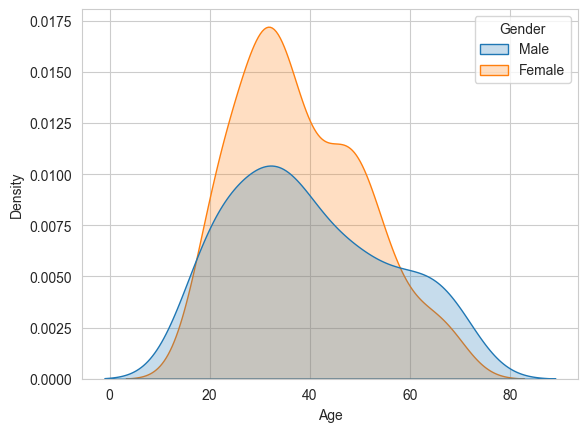

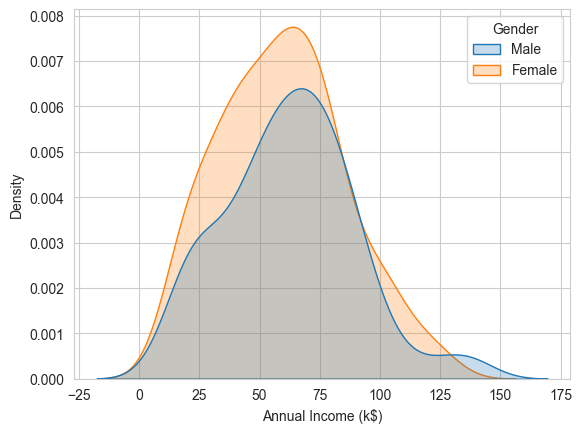

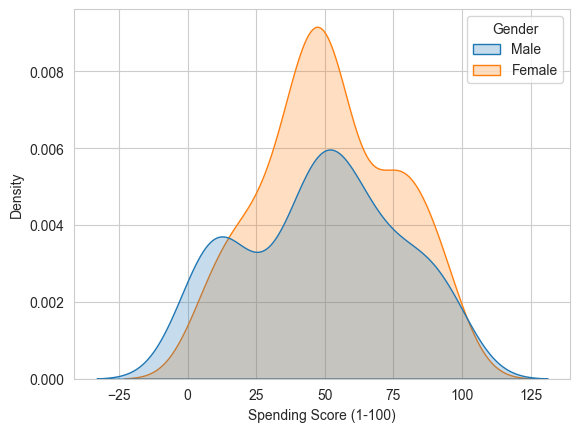

In [5]:
for i in columns:
    plt.figure()
    sns.kdeplot(x=df[i], shade=True, hue=df["Gender"]);
# would like to know if income distribution has any different from different gender

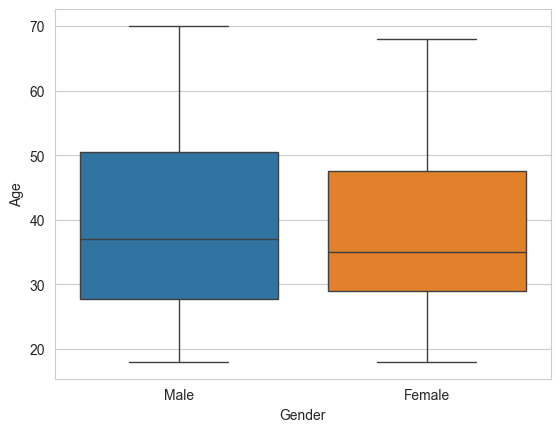

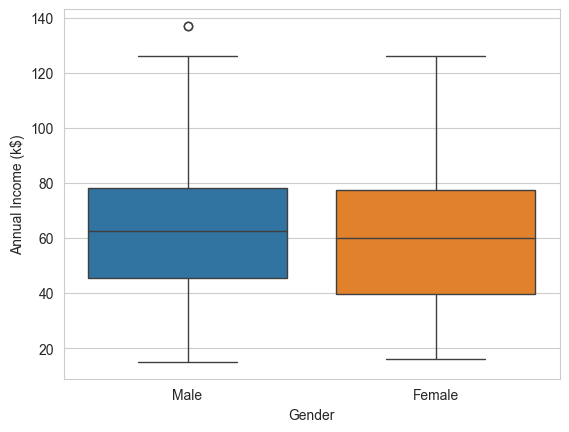

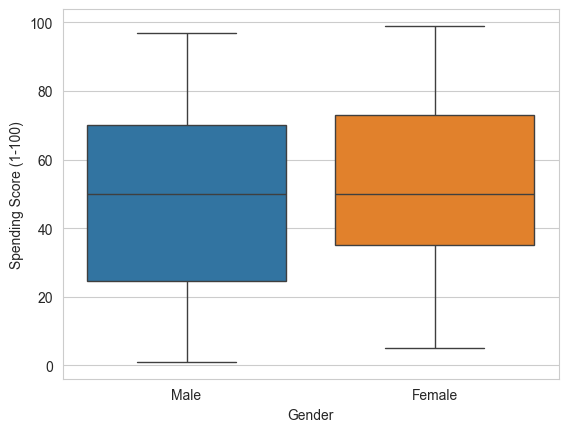

In [6]:
for i in columns:
    plt.figure()
    sns.boxplot(data=df, x='Gender', y=i, hue='Gender')
# Box plot is for checking med, area, intensity and outlier(异常值）

# Bivariate Analysis

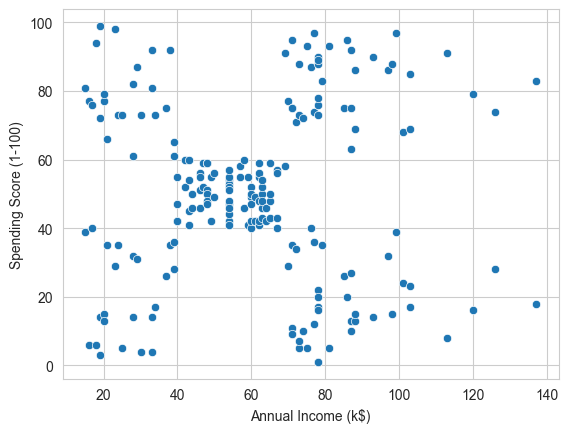

In [7]:
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)');
# 第一，看变量之间有没有明显关系。
# 比如 Annual Income 和 Spending Score 有没有一起变高，或者有没有分成几团。

# 第二，看有没有适合 clustering 的结构。
# 在这个项目里，最重要的是看到 Annual Income 和 Spending Score 的散点图里，客户不是完全乱的，而是大概可以分成几群。
# 这个发现支持后面使用 K-Means clustering。
# 视频里也是用 pairplot 和 scatter plot 来观察这些变量之间的关系，再进入 clustering。#

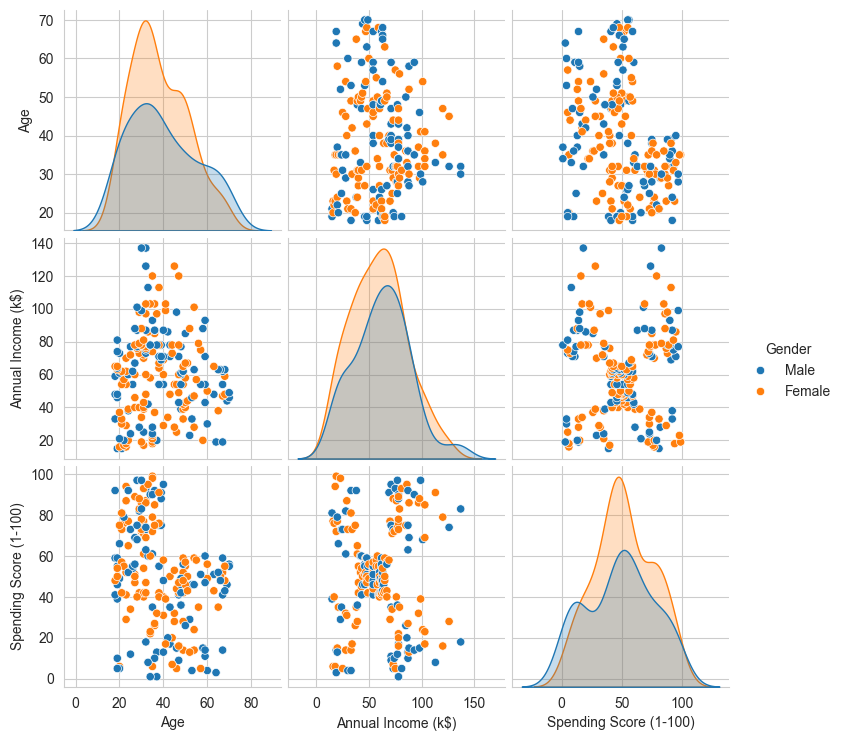

In [8]:
df = df.drop(columns=["CustomerID"])
sns.pairplot(df, hue="Gender");

In [9]:
df.groupby(['Gender'])[['Age', 'Annual Income (k$)',
       'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Gender,,,
Female,38.098214,59.250000,51.526786
Male,39.806818,62.227273,48.511364


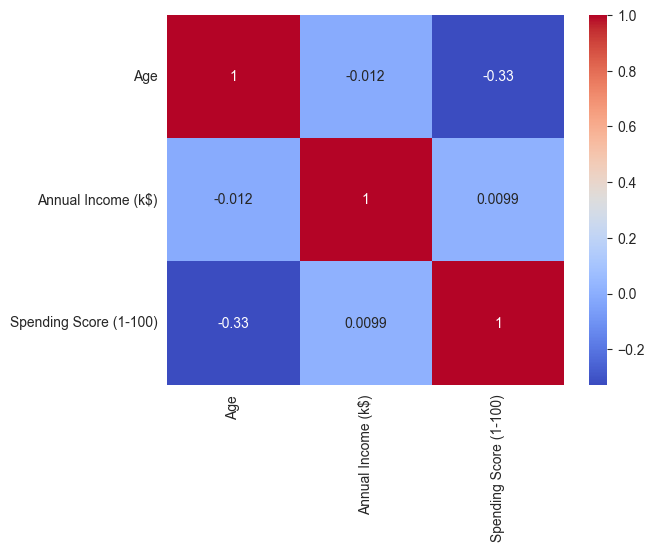

In [10]:
sns.heatmap(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr(), annot=True, cmap="coolwarm");

# Clustering - Univariate, Bivariate, Multivariate

In [11]:
clustering1 = KMeans(n_clusters=3)
clustering1.fit(df[['Annual Income (k$)']])
df['Income Cluster'] = clustering1.labels_
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster
0,Male,19,15,39,2
1,Male,21,15,81,2
2,Female,20,16,6,2
3,Female,23,16,77,2
4,Female,31,17,40,2


In [12]:
df['Income Cluster'].value_counts()
# in line35, size 8 is just a sample
# because we dont know ? will be good, so we need to use elbow method to find out 

Income Cluster
0    86
2    58
1    56
Name: count, dtype: int64

In [13]:
clustering1.inertia_
# how far every group is away from the center
# if the inertia is smaller, they are close to the center

25640.457784396836

In [14]:
inertia_scores = []

# Try different numbers of clusters, from 1 to 10
for i in range(1, 11):
    # Create a K-Means model with i clusters
    kmeans = KMeans(n_clusters=i)
    
    # Train the model using only Annual Income
    # This means we are testing how customers can be grouped by income level
    kmeans.fit(df[['Annual Income (k$)']])
    
    # Save the inertia score for this cluster number
    # Inertia means how far customers are from their cluster center
    # Smaller inertia means customers are closer to the center
    inertia_scores.append(kmeans.inertia_)

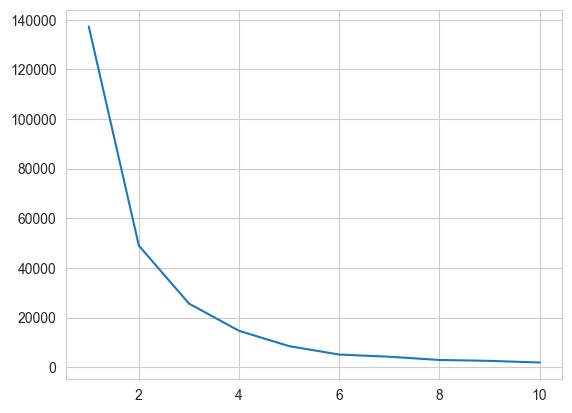

In [15]:
plt.plot(range(1, 11), inertia_scores);
# This loop tests different cluster numbers and saves their inertia scores, 
# so we can draw an elbow chart and choose a reasonable number of clusters.

In [16]:
df.groupby('Income Cluster')[['Age', 'Annual Income (k$)',
       'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Income Cluster,,,
0,41.279070,60.906977,50.337209
1,36.910714,92.142857,50.517857
2,37.120690,29.551724,49.689655


## Bivariate

In [17]:
clustering2 = KMeans(n_clusters=5)
clustering2.fit(df[['Annual Income (k$)', 'Spending Score (1-100)']])
df['Spending & Income Cluster'] = clustering2.labels_
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending & Income Cluster
0,Male,19,15,39,2,0
1,Male,21,15,81,2,1
2,Female,20,16,6,2,0
3,Female,23,16,77,2,1
4,Female,31,17,40,2,0


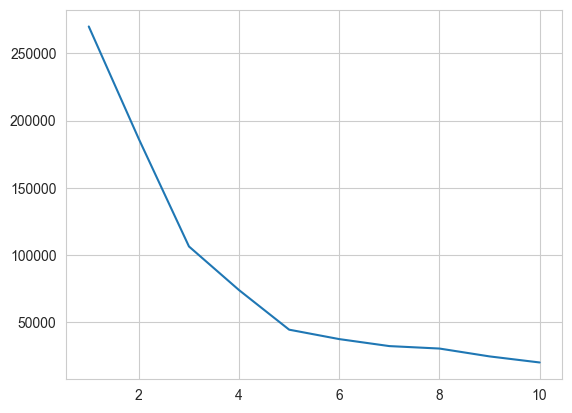

In [18]:
inertia_scores2 = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(df[['Annual Income (k$)', 'Spending Score (1-100)']])
    inertia_scores2.append(kmeans.inertia_)
    
plt.plot(range(1, 11), inertia_scores2);

In [19]:
centers = pd.DataFrame(clustering2.cluster_centers_)
centers.columns = ['x', 'y']

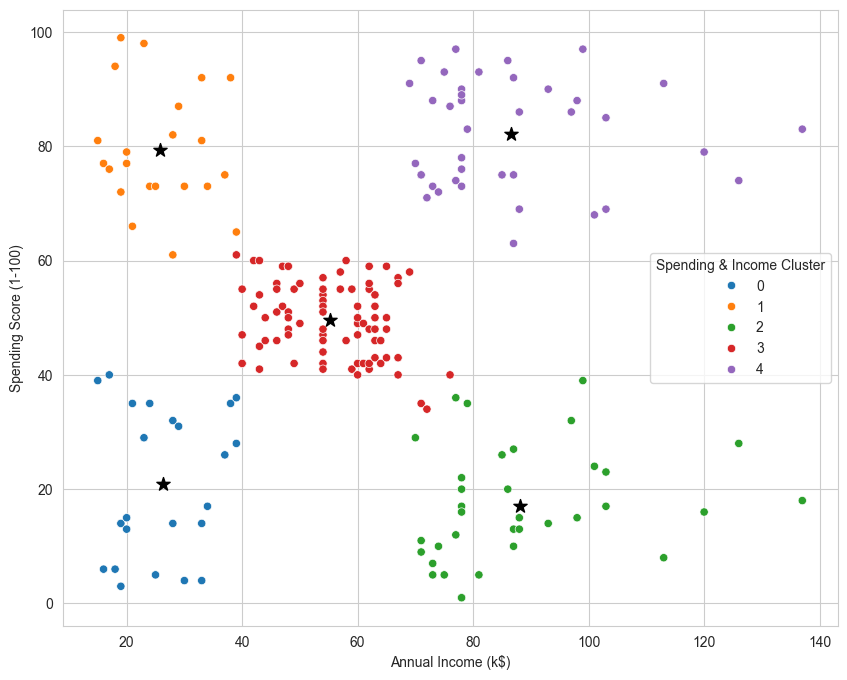

In [35]:
plt.figure(figsize=(10, 8))

sns.scatterplot(data=df,x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='Spending & Income Cluster',
    palette='tab10'
)

plt.scatter(centers['x'], centers['y'], c='black', marker='*', s=100)


In [21]:
pd.crosstab(df['Spending & Income Cluster'], df['Gender'], normalize='index')

Gender,Female,Male
Spending & Income Cluster,,
0,0.608696,0.391304
1,0.590909,0.409091
2,0.457143,0.542857
3,0.592593,0.407407
4,0.538462,0.461538


In [22]:
df.groupby('Spending & Income Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Spending & Income Cluster,,,
0,45.217391,26.304348,20.913043
1,25.272727,25.727273,79.363636
2,41.114286,88.200000,17.114286
3,42.716049,55.296296,49.518519
4,32.692308,86.538462,82.128205


## Multivariate Cluster

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()
dff = pd.get_dummies(df, drop_first=True)

In [25]:
dff = dff[['Age', 'Annual Income (k$)', 'Spending Score (1-100)','Gender_Male']]
dff = pd.DataFrame(scaler.fit_transform(dff)) 

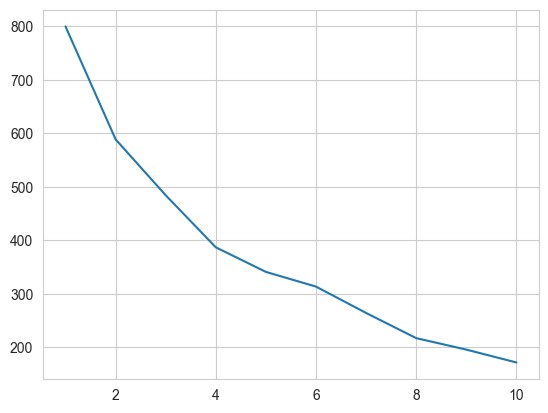

In [26]:
inertia_scores3 = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(dff)
    inertia_scores3.append(kmeans.inertia_)
    
plt.plot(range(1, 11), inertia_scores3);

In [27]:
clustering3 = KMeans(n_clusters=4)
clustering3.fit(dff)
df['Multivariate Cluster'] = clustering3.labels_
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending & Income Cluster,Multivariate Cluster
0,Male,19,15,39,2,0,0
1,Male,21,15,81,2,1,0
2,Female,20,16,6,2,0,0
3,Female,23,16,77,2,1,0
4,Female,31,17,40,2,0,0


In [28]:
df.groupby('Multivariate Cluster')[[
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Multivariate Cluster,,,
0,24.907407,39.666667,61.203704
1,49.204082,62.244898,29.734694
2,32.692308,86.538462,82.128205
3,47.224138,61.120690,35.775862
